In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["Target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64

In [5]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 569
Columns : 31


In [6]:
df["Target"].value_counts()

Target
1    357
0    212
Name: count, dtype: int64

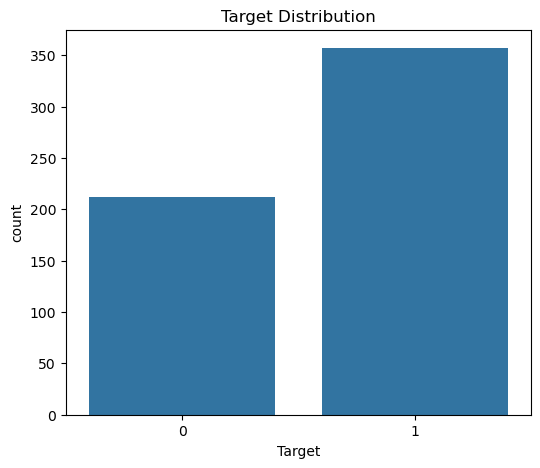

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Target",
    data=df
)

plt.title("Target Distribution")

plt.show()

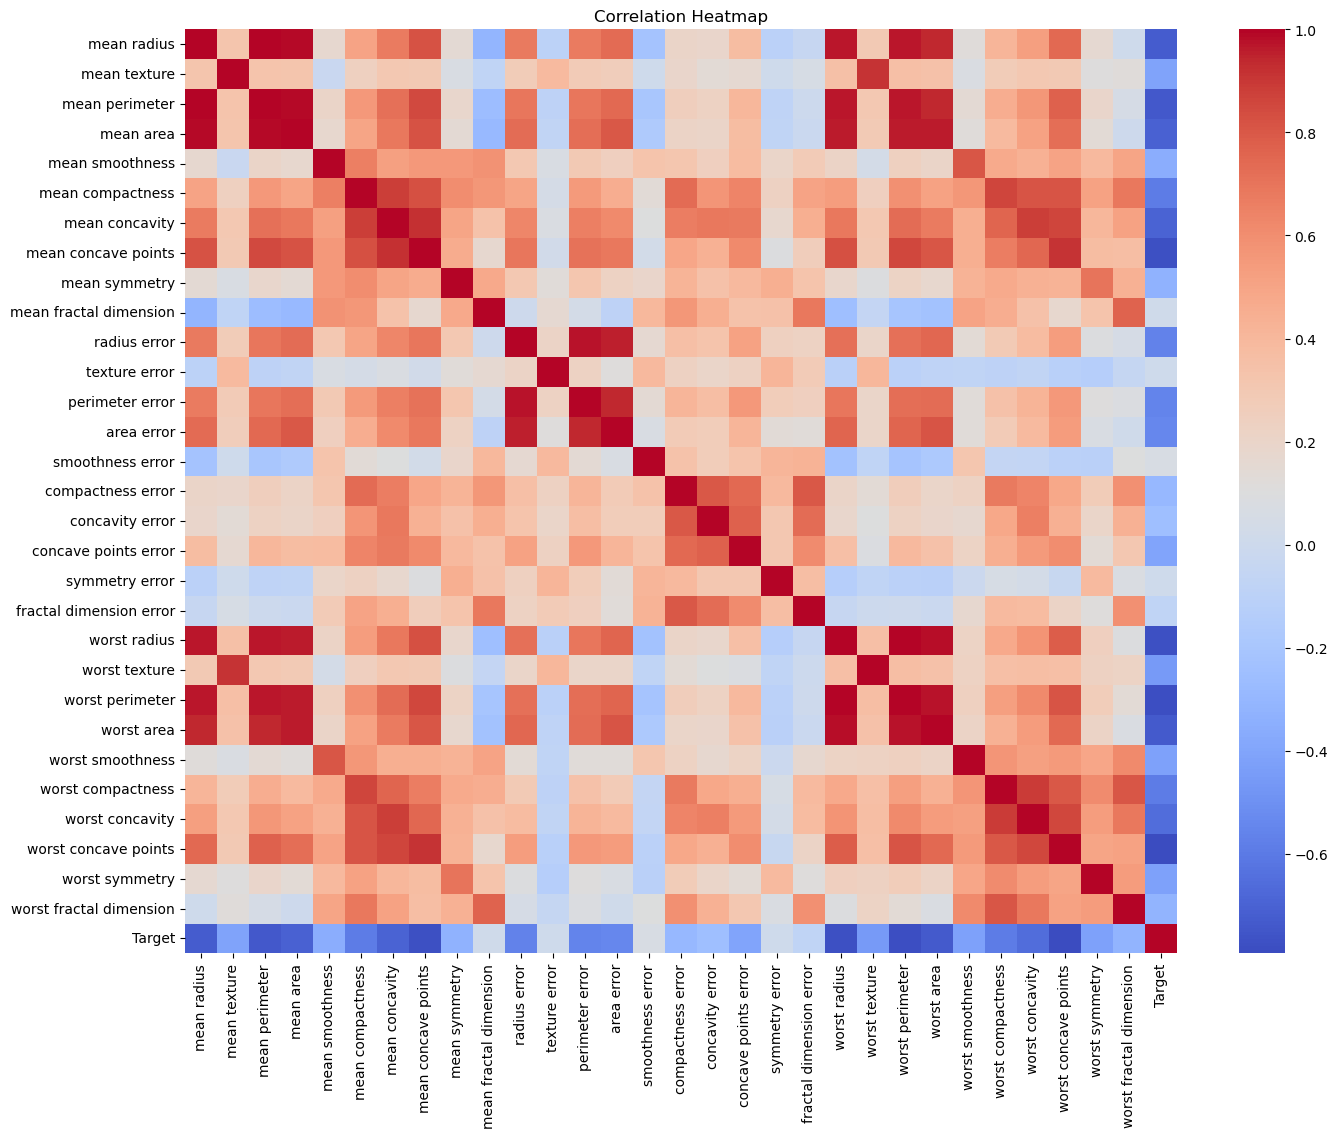

In [8]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
X = df.drop("Target",axis=1)

y = df["Target"]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :",accuracy)

Accuracy : 0.9736842105263158


In [15]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



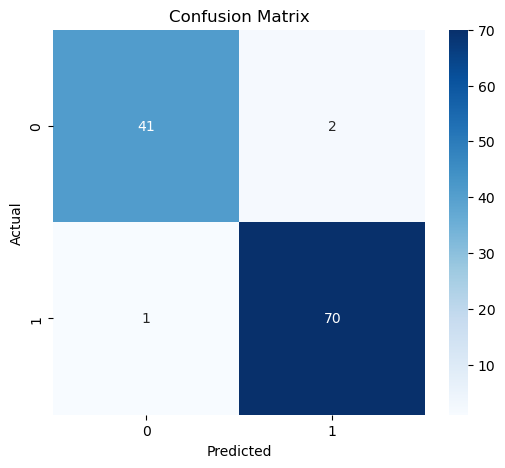

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

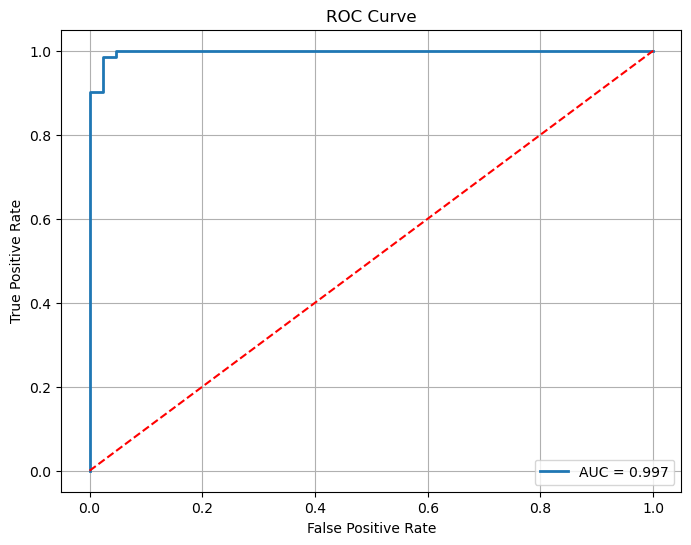

AUC Score : 0.99737962659679


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f"AUC = {auc_score:.3f}",
         linewidth=2)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

print("AUC Score :",auc_score)

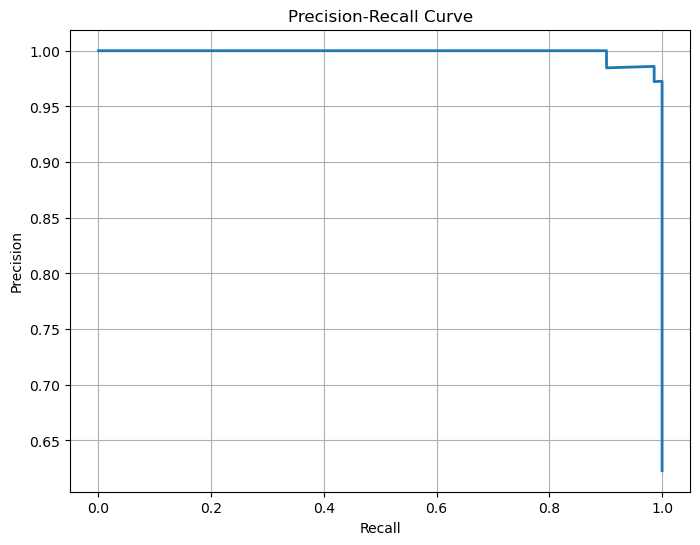

In [18]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [19]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance.head(10)

,Feature,Coefficient
21,worst texture,-1.350606
10,radius error,-1.268178
28,worst symmetry,-1.208200
7,mean concave points,-1.119804
26,worst concavity,-0.943053
13,area error,-0.907186
20,worst radius,-0.879840
23,worst area,-0.841846
6,mean concavity,-0.801458
27,worst concave points,-0.778217


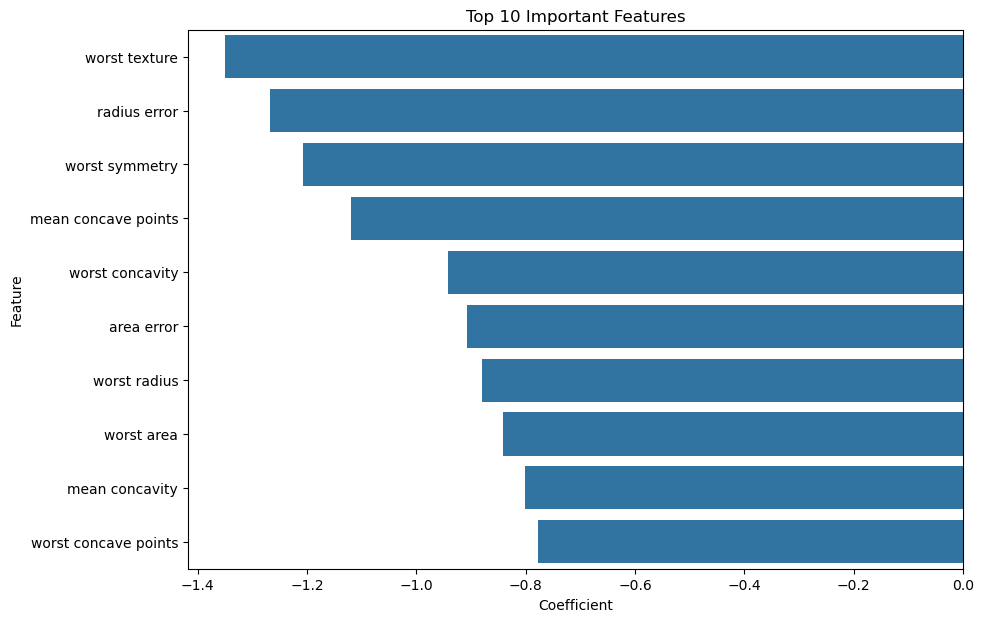

In [20]:
plt.figure(figsize=(10,7))

sns.barplot(

    x="Coefficient",

    y="Feature",

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

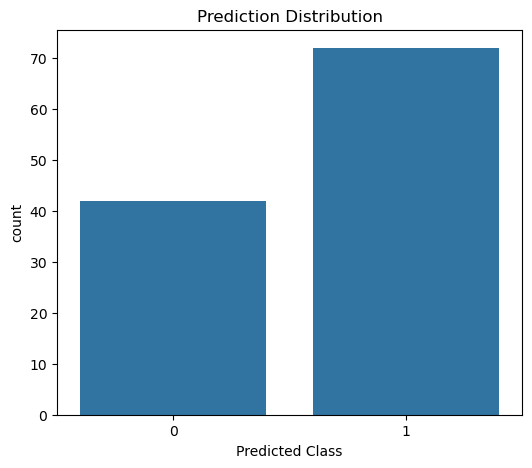

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_pred
)

plt.title("Prediction Distribution")

plt.xlabel("Predicted Class")

plt.show()

In [22]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":y_pred

})

comparison.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


In [23]:
comparison[
    comparison["Actual"] != comparison["Predicted"]
]

,Actual,Predicted
20,0,1
77,0,1
112,1,0


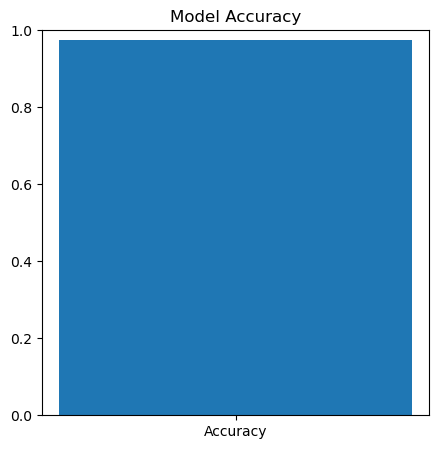

In [24]:
plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy]
)

plt.ylim(0,1)

plt.title("Model Accuracy")

plt.show()

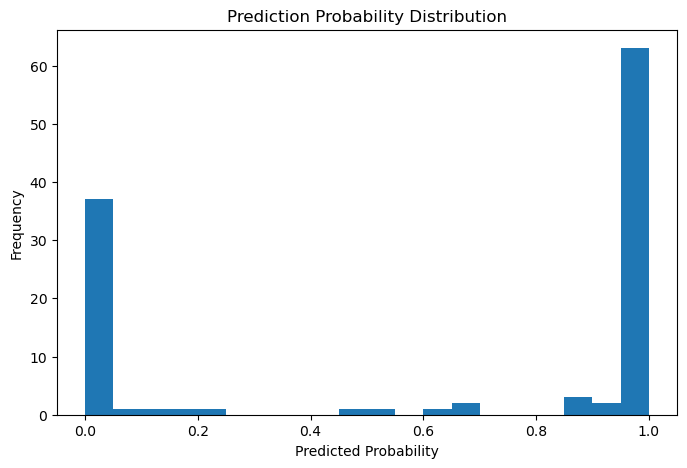

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=20
)

plt.xlabel("Predicted Probability")

plt.ylabel("Frequency")

plt.title("Prediction Probability Distribution")

plt.show()

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [27]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy :",dt_accuracy)

Decision Tree Accuracy : 0.9473684210526315


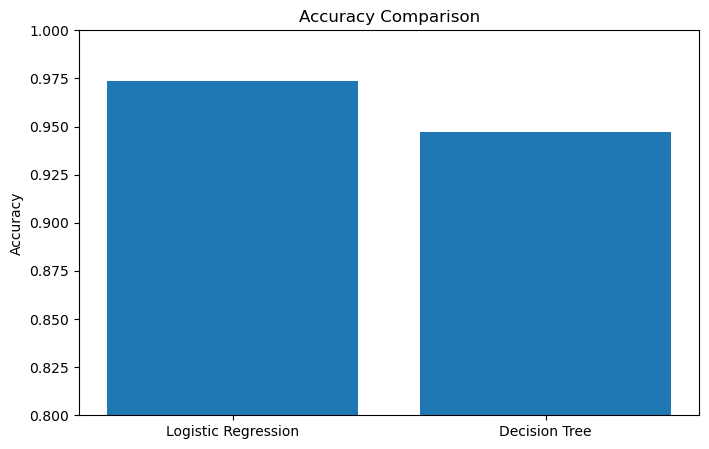

In [28]:
models = [
    "Logistic Regression",
    "Decision Tree"
]

accuracies = [
    accuracy,
    dt_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.8,1)

plt.show()

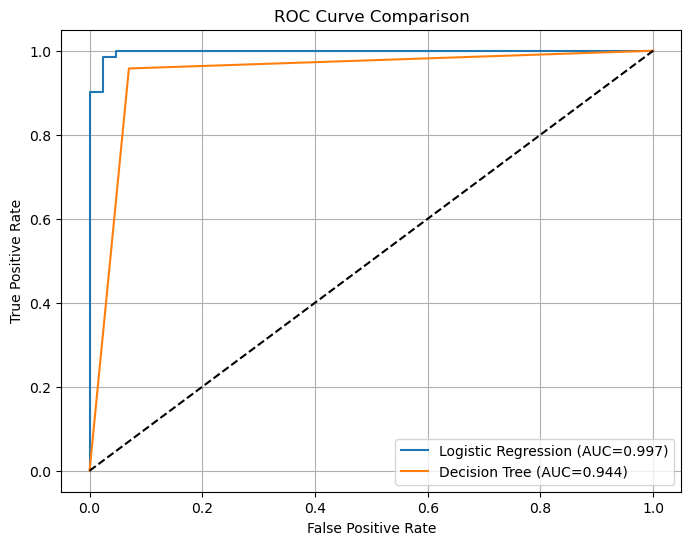

In [29]:
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC={auc_score:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={dt_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.show()

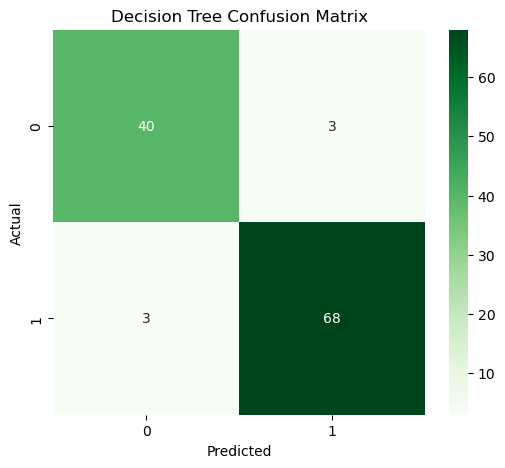

In [30]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    dt_pred
))

In [31]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy
    ],

    "AUC":[
        auc_score,
        dt_auc
    ]

})

comparison

,Model,Accuracy,AUC
0,Logistic Regression,0.973684,0.99738
1,Decision Tree,0.947368,0.94399


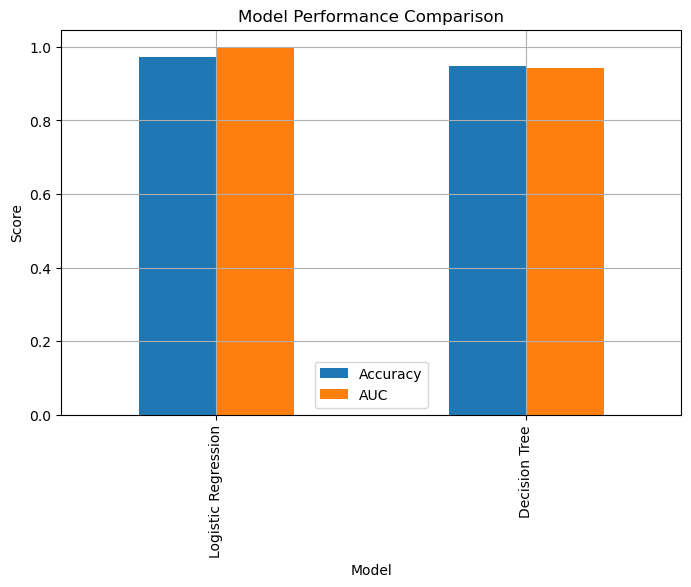

In [32]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.grid()

plt.show()

In [33]:
if accuracy > dt_accuracy:
    print("Best Model : Logistic Regression")
else:
    print("Best Model : Decision Tree")

Best Model : Logistic Regression
